In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

from team_project.helper.parsing import PROJECT_ROOT
from team_project.data.preprocessing import (
    clean_price,
    feature_summary,
    simplify_property_type,
)
from team_project.data.feature_construction import (
    AMENITY_PATTERNS,
    add_amenity_features,
    add_capacity_features,
    add_bathroom_features,
    add_distance_to_city_center,
    add_license_features,
)

In [82]:
# Global aesthetic settings
plt.rcParams["figure.dpi"] = 120  # Crisp resolution

sns.set_theme(
    style="ticks",
    font="sans-serif",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

# Motivation
The purpose of this notebook is to expand on the feature set that we used initially, for the first few models.
Running the models we realized quickly, that the error term was very high, worse than predicting the mean.

Therefore we need more features that have meaningful predicting values, we looked at the data again, closer this time.

In [83]:
raw_data = pd.read_csv(PROJECT_ROOT / 'data/raw/listings.csv.gz', low_memory=False)

# Closer look at the data

We had a closer look at the data, checking what features are usable, which may be redundant and which may leak data.
We put them into groups 

## The prediction problem
All `last_scraped` values are 2025-09-27, thus we are predicting the price scraped at 2025-09-27.

We are trying to predict price, so features like `estimated_revenue_l365d` is very likely leaking information.

# Price


## Missing values

In [84]:
total = len(raw_data)
missing = total - raw_data['price'].count()
print(f"There are {missing} missing target values, that is {missing/total * 100:.2f}% of the data")

There are 2671 missing target values, that is 32.28% of the data


The following code checks if all the price data follows the pattern we assume it does.

In [85]:
pattern = r"\$[0-9]*,?[0-9]+\.[$0-9]+"
mask = raw_data['price'].dropna().str.fullmatch(pattern).all()

As we can see, it does indeed follow that assumption, so we can clean it by just removing '$' and ',' and then converting to a float.

In [86]:
df = raw_data.dropna(subset=["price"]).copy()
df = clean_price(df)

## Outliers

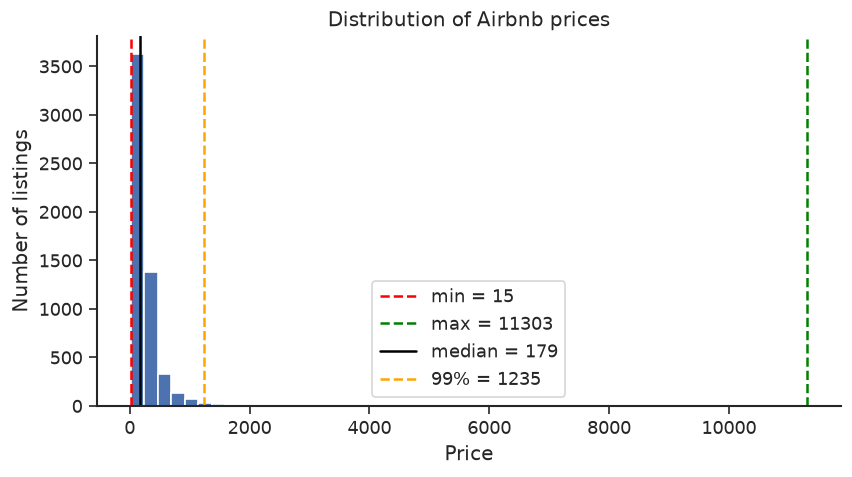

In [87]:
price = df['price']
plt.figure(figsize=(8, 4))
plt.hist(price, bins=50)


plt.axvline(price.min(), color="red", linestyle="--", label=f"min = {price.min():.0f}")
plt.axvline(price.max(), color="green", linestyle="--", label=f"max = {price.max():.0f}")
plt.axvline(price.median(), color="black", linestyle="-", label=f"median = {price.median():.0f}")
plt.axvline(price.quantile(0.99), color="orange", linestyle="--", label=f"99% = {price.quantile(0.99):.0f}")

plt.legend()
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb prices")
plt.show()

This looks really suspicous, so lets check the extremes:

In [88]:
price.describe()

count        5603.0
mean     263.736034
std      433.757852
min            15.0
25%           112.0
50%           179.0
75%           300.0
max         11303.0
Name: price, dtype: Float64

15$ seems like a reasonable price, but 11303$ seems suspecious, so lets inspect those data points closer.

In [89]:
upper = price.quantile(0.99)
high_price_df = df[price > upper]
print(high_price_df['property_type'].unique())
print(high_price_df['room_type'].unique())

<ArrowStringArray>
[         'Entire rental unit',                'Entire condo',
                 'Entire loft',                'Entire villa',
                 'Entire home', 'Private room in rental unit']
Length: 6, dtype: str
<ArrowStringArray>
['Entire home/apt', 'Private room']
Length: 2, dtype: str


As we can see, it is entire rental units or entire homes, which explains the price. No only entries with 'Private room in rental unit' seem odd.


In [90]:
odd = high_price_df[high_price_df['room_type'] == 'Private room']
print(odd['accommodates'])
print(odd['price'])
print(odd.loc[3772, 'description'])
print(odd.loc[5797, 'description'])

3772    1
5797    2
Name: accommodates, dtype: int64
3772    3000.0
5797    2421.0
Name: price, dtype: Float64
Quiet attic room, within walking distance of the "Alte Heide" U-Bahn [subway] station (<5 min.). The room (separate area with private entrance) is equipped with a double bed as well as a single bed, a desk, TV and Wi-Fi. The bathroom is shared with the host. The English Garden, restaurants and shops serving daily needs are around the corner.<br />Note: The apartment is on the third floor - attic, no elevator, sloping walls on the window side. Linens and towels are provided.
Enjoy the simple life in this quiet and centrally located home.


Still seems expensive, but not that unrasonable for use to exclude it, so overall, the price data looks fine.
Models should be able to predict outliers based on the `room_type` feature.
Lets check if all 'Entire home/apt' are that expensive.

In [91]:
print(df['room_type'].unique())
print(df['property_type'].unique())
ENTIRE_HOME = 'Entire home/apt'
df[df['room_type'] == ENTIRE_HOME]['price'].describe()

<ArrowStringArray>
['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
Length: 4, dtype: str
<ArrowStringArray>
[                'Entire rental unit',               'Private room in home',
        'Private room in rental unit',                        'Entire loft',
              'Private room in condo',                   'Entire townhouse',
 'Private room in serviced apartment',              'Private room in villa',
                       'Entire condo',                        'Entire home',
         'Shared room in rental unit',          'Private room in townhouse',
                       'Private room',  'Private room in bed and breakfast',
               'Private room in loft',                 'Room in aparthotel',
                  'Entire guesthouse',        'Private room in guest suite',
             'Private room in hostel',                    'Entire bungalow',
          'Entire serviced apartment',                 'Entire guest suite',
                       'Enti

count        3722.0
mean     318.871037
std      512.176609
min            31.0
25%           144.0
50%           225.0
75%           353.0
max         11303.0
Name: price, dtype: Float64

This seems really suspecious, room type might be noisier than expected, let's check it combined with the property type.

In [92]:
mask = (df['room_type'] == ENTIRE_HOME) & ~(df['property_type'].str.contains("Entire", na=False))
df[mask]['property_type']

132     Room in aparthotel
133     Room in aparthotel
1769                   Hut
1984    Room in aparthotel
2221    Room in aparthotel
2308    Room in aparthotel
2357    Room in aparthotel
2632               Pension
2997             Camper/RV
3362    Room in aparthotel
4015             Camper/RV
4262             Camper/RV
4298             Tiny home
4425             Tiny home
4688              Windmill
5640    Room in aparthotel
5684                  Tent
6373    Room in aparthotel
6374    Room in aparthotel
6375    Room in aparthotel
6681    Room in aparthotel
7115             Tiny home
7523    Room in aparthotel
7528    Room in aparthotel
7830             Tiny home
7952             Tiny home
8000             Tiny home
8126             Camper/RV
Name: property_type, dtype: str

Okay this makes sense, a camper could count as a full apartment or home but can still be non expensive. The combination of those features seems important, lets check.

In [93]:
df.groupby(["room_type", "property_type"])["price"].agg(
["count", "median", "mean"]
).sort_values("count", ascending=False)

count  median        mean
room_type       property_type                                                
Entire home/apt Entire rental unit                   3051   225.0  312.838741
Private room    Private room in rental unit          1224   115.0  140.815359
                Private room in home                  269   112.0  132.200743
Entire home/apt Entire condo                          258   253.0  326.810078
                Entire serviced apartment             202   210.0  291.668317
Private room    Private room in condo                 112   121.5  137.758929
                Room in hotel                          75   311.0  352.133333
Entire home/apt Entire home                            70   306.5  431.557143
                Entire loft                            67   293.0  470.283582
Private room    Private room in townhouse              51    95.0  111.176471
                Private room in bed and breakfast      28   119.5  164.785714
Shared room     Shared room in rental unit             19    91.0  105.789474
Entire home/apt Entire townhouse                       16   403.0    430.8125
Private room    Room in boutique hotel                 15   325.0  367.466667
Entire home/apt Room in aparthotel                     14   343.5       379.5
Private room    Private room in hostel                 13   999.0  832.692308
                Room in aparthotel                     12   273.0  316.916667
Entire home/apt Entire villa                            8  1074.0     983.375
Private room    Private room in serviced apartment      7    66.0  219.714286
Entire home/apt Entire guesthouse                       7   155.0  184.714286
Private room    Private room in guesthouse              7    80.0   87.714286
Entire home/apt Tiny home                               6   100.0  120.833333
Private room    Private room in loft                    6   151.0  234.166667
                Private room in tent                    6    90.0   86.833333
Entire home/apt Entire guest suite                      5   159.0       212.4
Hotel room      Room in hotel                           5    90.0       174.4
Private room    Private room                            4    73.0        80.5
Hotel room      Room in boutique hotel                  4   244.0      255.25
Private room    Private room in casa particular         4    73.5       103.0
Entire home/apt Camper/RV                               4    86.0        97.5
Private room    Private room in guest suite             3   121.0  127.333333
Entire home/apt Entire vacation home                    3   365.0  341.666667
                Entire bungalow                         3   347.0       308.0
Private room    Private room in villa                   3    85.0   93.333333
                Private room in vacation home           3    41.0   67.666667
Shared room     Shared room in condo                    2   135.5       135.5
                Shared room in home                     2    36.0        36.0
Hotel room      Room in serviced apartment              2   179.0       179.0
Entire home/apt Entire place                            2   431.0       431.0
                Hut                                     1   103.0       103.0
                Entire cabin                            1    86.0        86.0
                Entire chalet                           1   428.0       428.0
                Pension                                 1   100.0       100.0
Private room    Private room in farm stay               1   148.0       148.0
Entire home/apt Tent                                    1   119.0       119.0
                Windmill                                1   225.0       225.0
Hotel room      Room in bed and breakfast               1    82.0        82.0
Private room    Private room in camper/rv               1    38.0        38.0
Shared room     Shared room in bed and breakfast        1    73.0        73.0
                Shared room in tipi                     1    70.0        7

In [94]:
df['property_type_clean'] = df['property_type'].apply(simplify_property_type)
df.groupby("property_type_clean")["price"].agg(["count", "median", "mean"])


,count,median,mean
property_type_clean,,,
apartment_like,4739,180.0,266.252374
hotel_like,169,287.0,346.893491
house_like,463,125.0,202.710583
other,7,80.0,179.142857
serviced_apartment,211,204.0,288.21327
unusual_stay,14,94.5,99.714286


The cleaned property type feature appears useful because categories have distinct median prices, meaning, they seperate the data into different price classes.

However, the rare categories `other` and `unusual_stay` have very small counts, so their estimates are unstable. They should possibly be combined into a single `rare_or_unusual` category.

In [95]:
df["property_type_clean"] = df["property_type_clean"].replace({
    "other": "rare_or_unusual",
    "unusual_stay": "rare_or_unusual",
})
df.groupby("property_type_clean")["price"].agg(["count", "median", "mean"])

,count,median,mean
property_type_clean,,,
apartment_like,4739,180.0,266.252374
hotel_like,169,287.0,346.893491
house_like,463,125.0,202.710583
rare_or_unusual,21,89.0,126.190476
serviced_apartment,211,204.0,288.21327


# Log Price

Since the prices are right skewed, so the model would treat those two the same:
```
true price = 100, predicted = 200   error = 100
true price = 1000, predicted = 1100 error = 100
```
We want the model to be more sensitive where more of the listings lie,
we want the relative errors to matter, thus log1 price is a good option to predict.

In [96]:
df["log_price"] = np.log1p(df["price"])

log price prevents expensive outliers from dominating training, and it gives more practical attention to the cheaper/common listings where we have many more examples.

# Structural and location features
The earlier analysis already established that `room_type` combined with `property_type_clean` has predictive power. The remaining raw structural columns are checked and engineered below.

Completed feature checklist:

- [x] latitude and longitude
- [x] property_type (completed above)
- [x] room_type (completed above)
- [x] accommodates
- [x] bathrooms and bathrooms_text
- [x] license
- [x] bedrooms and beds
- [x] amenities
- [x] neighbourhood_cleansed

In [97]:
STRUCTURAL_COLUMNS = [
    "latitude", "longitude", "neighbourhood_cleansed",
    "accommodates", "bathrooms", "bathrooms_text", "license",
    "bedrooms", "beds", "amenities",
]
feature_summary(df, STRUCTURAL_COLUMNS)

,dtype,missing_count,missing_percent,unique_values
latitude,float64,0,0.00,4867
longitude,float64,0,0.00,4997
neighbourhood_cleansed,str,0,0.00,25
accommodates,int64,0,0.00,14
bathrooms,float64,4,0.07,12
bathrooms_text,str,4,0.07,23
license,str,5572,99.45,17
bedrooms,float64,8,0.14,10
beds,float64,1,0.02,21
amenities,str,0,0.00,5120


## Location

The raw coordinates retrain the exact spatial information, while `neighbourhood_cleansed` groups the data into districts.
`distance_city_center` provides a simple nonlinear summary feature.

In [98]:
df = add_distance_to_city_center(df)
df[["latitude", "longitude", "distance_to_city_center_km"]].describe()

,latitude,longitude,distance_to_city_center_km
count,5603.000000,5603.000000,5603.000000
mean,48.139873,11.560174,4.169699
std,0.026850,0.051298,2.715503
min,48.068048,11.386690,0.034706
25%,48.122289,11.536318,2.092939
50%,48.137040,11.563356,3.435276
75%,48.156936,11.585084,5.673540
max,48.228020,11.716110,14.392422


In [99]:
df.groupby("neighbourhood_cleansed")["price"].agg(
    count="size", median_price="median", mean_price="mean"
).sort_values("median_price", ascending=False)

,count,median_price,mean_price
neighbourhood_cleansed,,,
Altstadt-Lehel,210,321.5,403.057143
Ludwigsvorstadt-Isarvorstadt,665,285.0,450.526316
Schwanthalerhöhe,186,247.5,314.295699
Maxvorstadt,429,225.0,290.522145
Sendling,182,218.0,267.505495
Au-Haidhausen,297,202.0,270.363636
Neuhausen-Nymphenburg,312,182.0,247.198718
Schwabing-Freimann,275,171.0,242.803636
Bogenhausen,252,168.0,220.722222


All modelling rows have coordinates and a cleaned neighbourhood. The furthest listings are about 14.4 km from the centre and belong to `Aubing-Lochhausen-Langwied`, an outer Munich district. 

+ For preprocessing, we one-hot encode `neighbourhood_cleansed` with unknown-category handling. 

+ We scale latitude, longitude, and distance for linear or distance-based models
+ Tree models can use them without scaling.

## Capacity, bedrooms, and beds

`accommodates` is complete and has a valid minimum of one, so it can remain a numeric count. Missing bedrooms and beds should get a missing indicator combined with imputation.

In [100]:
df = add_capacity_features(df)
df[["accommodates", "bedrooms", "bedrooms_missing", "beds", "beds_missing"]].describe()

,accommodates,bedrooms,bedrooms_missing,beds,beds_missing
count,5603.000000,5595.000000,5603.000000,5602.000000,5603.000000
mean,2.901660,1.228776,0.001428,1.723135,0.000178
std,1.782778,0.971820,0.037763,1.594804,0.013359
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,1.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000
75%,4.000000,1.000000,0.000000,2.000000,0.000000
max,16.000000,50.000000,1.000000,50.000000,1.000000


The priced sample has only 8 missing bedroom values and 1 missing bed value. 
+ We use median imputation for `bedrooms` and `beds` during model preprocessing while retaining `bedrooms_missing` and `beds_missing`. 
+ We impute `bedrooms` and `beds`

In [101]:
feature_summary(df, ['accommodates', 'bedrooms', 'bedrooms_missing', 'beds', 'beds_missing'])

,dtype,missing_count,missing_percent,unique_values
accommodates,int64,0,0.00,14
bedrooms,float64,8,0.14,10
bedrooms_missing,int8,0,0.00,2
beds,float64,1,0.02,21
beds_missing,int8,0,0.00,2


## Bathrooms

`bathrooms_text` is more complete than the numeric field in the full raw data. It encodes both the count and whether a bathroom is explicitly private or shared. Half-baths are represented as 0.5. A plain value such as `1 bath` is deliberately not marked private because the source does not explicitly say so.

In [102]:
df['bathrooms_text'].unique()

<ArrowStringArray>
[           '1 bath',     '1 shared bath',         '1.5 baths',
                 nan,    '1 private bath',           '2 baths',
           '3 baths',  '1.5 shared baths',  '2.5 shared baths',
           '0 baths',         '2.5 baths',         'Half-bath',
    '2 shared baths',    '0 shared baths',  'Shared half-bath',
         '3.5 baths',    '4 shared baths',    '3 shared baths',
 'Private half-bath',           '4 baths',           '8 baths',
           '5 baths',           '6 baths',    '6 shared baths']
Length: 24, dtype: str

In [103]:
df = add_bathroom_features(df)
feature_summary(df, [
    "bathroom_count", "bathroom_privacy", "bathroom_information_missing"])

,dtype,missing_count,missing_percent,unique_values
bathroom_count,float64,4,0.07,12
bathroom_privacy,str,0,0.00,4
bathroom_information_missing,int8,0,0.00,2


+ Median-impute `bathroom_count` inside the training pipeline and retain `bathroom_information_missing`
+ One hot encode `bathroom_privacy`

## License

Only 31 of the 5,603 priced listings contain a license value. The 17 observed strings mix register numbers, tax-like identifiers, phone-like values, and free text. Most occur once, so `license_type` would create arbitrary, extremely sparse categories. 
Thus the only reasonable feature would be `has_license`.

In [104]:
df = add_license_features(df)
df["has_license"].value_counts(dropna=False).rename_axis("has_license").to_frame("listings")

,listings
has_license,
0,5572
1,31


`has_license` needs no imputation or encoding. 
It may add no stable predictive value, so it should be tested against cross validation.

## Amenities

Every raw amenities value is a valid JSON list. Parsing JSON is important because commas may occur inside amenity names. 

In [105]:
df['amenities'].unique()

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [106]:
df = add_amenity_features(df)
df[["amenity_count", *AMENITY_PATTERNS]].describe().T

,count,mean,std,min,25%,50%,75%,max
amenity_count,5603.0,26.008210,15.528185,0.0,11.0,26.0,38.0,92.0
has_wifi,5603.0,0.942174,0.233435,0.0,1.0,1.0,1.0,1.0
has_kitchen,5603.0,0.891308,0.311280,0.0,1.0,1.0,1.0,1.0
has_parking,5603.0,0.617705,0.485991,0.0,0.0,1.0,1.0,1.0
has_washer,5603.0,0.751740,0.432042,0.0,1.0,1.0,1.0,1.0
has_air_conditioning,5603.0,0.072997,0.260154,0.0,0.0,0.0,0.0,1.0
has_workspace,5603.0,0.586828,0.492447,0.0,0.0,1.0,1.0,1.0
has_balcony,5603.0,0.280386,0.449228,0.0,0.0,0.0,1.0,1.0
has_dryer,5603.0,0.250402,0.433283,0.0,0.0,0.0,1.0,1.0
has_elevator,5603.0,0.291451,0.454471,0.0,0.0,0.0,1.0,1.0


Binary amenity features require no imputation. 
+ `amenity_count` can remain numeric and should be scaled for scale-sensitive models. 
+ An empty list correctly produces a count of zero; it is not treated as missing information.

## Summary structural features

In [107]:
ENGINEERED_STRUCTURAL_COLUMNS = [
    "distance_to_city_center_km",
    "bedrooms_missing", "beds_missing",
    "bathroom_count", "bathroom_privacy",
    "bathroom_information_missing", "has_license", "amenity_count",
    *AMENITY_PATTERNS,
]
feature_summary(df, ENGINEERED_STRUCTURAL_COLUMNS)

,dtype,missing_count,missing_percent,unique_values
distance_to_city_center_km,float64,0,0.00,5290
bedrooms_missing,int8,0,0.00,2
beds_missing,int8,0,0.00,2
bathroom_count,float64,4,0.07,12
bathroom_privacy,str,0,0.00,4
bathroom_information_missing,int8,0,0.00,2
has_license,int8,0,0.00,2
amenity_count,int16,0,0.00,78
has_wifi,int8,0,0.00,2
has_kitchen,int8,0,0.00,2
